# SARIMA + Prophet (법정동 단위) — v2

1. **전체 동 대상**으로 실행 (기존엔 거래건수 상위 20개 동만 테스트)
2. **horizon(1~12개월 뒤)별 오차 분해** — 지금까지는 1개월 뒤 예측과 12개월 뒤 예측 오차를 한 덩어리로 평균 내서, 뒤로 갈수록 오차가 커지는지 안 보였음
3. **naive baseline** 추가 — 마지막 관측값을 그대로 다음 달 예측치로 쓰는 가장 단순한 방법과 비교. SARIMA/Prophet이 이보다 못하면 복잡한 모델을 쓸 이유가 없음

**입력**: `raw_series_dong.csv` (lag/rolling/target 없는 원본 월별 패널)

* SARIMA: 과거 자기 자신의 값(AR), 차분을 통한 추세 제거(I), 과거 오차(MA), 그리고 12개월 계절 주기를 함께 모델링하는 전통적 시계열 모델. 동마다 개별적으로 하나씩 학습.
* Prophet: 추세(trend) + 연간 계절성(yearly seasonality)을 분해해서 적합시키는 모델. SARIMA보다 결측치·불규칙한 데이터에 상대적으로 강건하다고 알려져 있음.
* Naive baseline: 마지막으로 관측된 월세를 그대로 다음 달들의 예측치로 사용하는, 비교 기준점 역할의 가장 단순한 방법.

## 0. 환경 설치 / 라이브러리

In [1]:
# Colab에 prophet이 없다면 아래 주석을 풀어서 설치
# !pip install prophet --quiet

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

## 1. 원본 시계열 패널 로드

In [3]:
raw = pd.read_csv("raw_series_dong.csv", encoding="utf-8-sig")
raw['계약일'] = pd.to_datetime(raw['계약일'])

print(raw.shape)
print("법정동 수:", raw['법정동코드'].nunique())
raw.head()

(11222, 12)
법정동 수: 62


,법정동코드,계약연도,계약월,월세,보증금,평균평수,평균평당가격,거래건수,자치구코드,자치구명,법정동명,계약일
0,10100.0,2011,1,32.666667,1033.333333,9.135859,4.000523,12.0,11620.0,관악구,봉천동,2011-01-01
1,10100.0,2011,2,29.687500,1475.000000,10.716288,2.910525,16.0,11620.0,관악구,봉천동,2011-02-01
2,10100.0,2011,3,30.846154,1232.692308,9.389277,3.777229,26.0,11620.0,관악구,봉천동,2011-03-01
3,10100.0,2011,4,30.153846,1753.846154,9.636713,3.769842,26.0,11620.0,관악구,봉천동,2011-04-01
4,10100.0,2011,5,37.055556,1094.444444,9.987710,4.210361,18.0,11620.0,관악구,봉천동,2011-05-01


## 2. Train / Valid / Test 기간 정의

In [4]:
TRAIN_END = pd.Timestamp('2023-12-01')
VALID_START, VALID_END = pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-01')
TEST_START, TEST_END = pd.Timestamp('2025-01-01'), pd.Timestamp('2025-12-01')

VALID_HORIZON = 12
TEST_HORIZON = 12

## 3. 동별 시계열 추출 함수

In [5]:
TARGET_COL = '평균평당가격'  # 나중에 '월세'로 다시 비교하고 싶으면 여기만 바꾸면 됨

def get_sarima_series(dong_code, end_date):
    sub = (
        raw[(raw['법정동코드'] == dong_code) & (raw['계약일'] <= end_date)]
        .sort_values('계약일')
        .set_index('계약일')[TARGET_COL]
    )
    return sub.asfreq('MS')


def get_prophet_df(dong_code, end_date):
    sub = (
        raw[(raw['법정동코드'] == dong_code) & (raw['계약일'] <= end_date)]
        [['계약일', TARGET_COL]]
        .dropna()
        .rename(columns={'계약일': 'ds', TARGET_COL: 'y'})
        .sort_values('ds')
    )
    return sub


def get_actual(dong_code, start_date, end_date):
    sub = (
        raw[(raw['법정동코드'] == dong_code) &
            (raw['계약일'] >= start_date) & (raw['계약일'] <= end_date)]
        .sort_values('계약일')
    )
    return sub.set_index('계약일')[TARGET_COL]

## 4. 모델별 학습/예측 함수 (SARIMA, Prophet, Naive)

In [6]:
def fit_forecast_sarima(series, steps, order=(1, 1, 1), seasonal_order=(0, 1, 1, 12)):
    train_vals = series.dropna()
    if train_vals.shape[0] < 24:
        return None
    try:
        model = SARIMAX(
            series, order=order, seasonal_order=seasonal_order,
            enforce_stationarity=False, enforce_invertibility=False,
        )
        fitted = model.fit(disp=False)
        forecast = fitted.forecast(steps=steps).values

        # 발산 방지: 학습 데이터 범위를 크게 벗어나는 예측은 사실상 모델 실패로 간주.
        # (단위근 근처 계열에서 SARIMA가 지수적으로 발산하는 경우가 흔함)
        train_min, train_max = train_vals.min(), train_vals.max()
        train_range = max(train_max - train_min, train_max * 0.5, 1.0)
        lower_bound = train_min - 5 * train_range
        upper_bound = train_max + 5 * train_range

        if np.any(forecast < lower_bound) or np.any(forecast > upper_bound) or np.any(~np.isfinite(forecast)):
            return None

        return forecast
    except Exception:
        return None


def fit_forecast_prophet(train_df, periods):
    if train_df.shape[0] < 24:
        return None
    try:
        model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        model.fit(train_df)
        future = model.make_future_dataframe(periods=periods, freq='MS')
        forecast = model.predict(future)
        return forecast.tail(periods)['yhat'].values
    except Exception:
        return None


def fit_forecast_naive(series, steps):
    # 가장 단순한 베이스라인: 마지막으로 관측된 값을 그대로 다음 달들의 예측치로 사용
    valid_vals = series.dropna()
    if valid_vals.shape[0] == 0:
        return None
    last_value = valid_vals.iloc[-1]
    return np.repeat(last_value, steps)

## 5. 대상 동 선정
`TEST_MODE = True`로 먼저 소수 동에서 파이프라인이 잘 도는지 확인한 뒤, `False`로 바꿔 전체 동으로 실행.

In [7]:
TEST_MODE = False   # 전체 동 대상 실행. 빠르게 확인만 하려면 True로.
N_SAMPLE = 20

dong_list = raw['법정동코드'].unique().tolist()

if TEST_MODE:
    top_dongs = (
        raw.groupby('법정동코드')['거래건수'].sum()
        .sort_values(ascending=False)
        .head(N_SAMPLE)
        .index.tolist()
    )
    dong_list = top_dongs

print("대상 동 개수:", len(dong_list))

대상 동 개수: 62


## 6. 예측 실행 (long format: 동 x horizon 단위로 한 행)
12개월치를 한 번에 평균 내지 않고, `horizon`(1~12) 컬럼을 남겨서 나중에 몇 개월 뒤 예측부터 오차가 커지는지 볼 수 있게 한다.

In [8]:
def run_forecast_loop(dong_list, train_end, actual_start, actual_end, horizon):
    rows = []

    for dong_code in dong_list:
        sarima_series = get_sarima_series(dong_code, train_end)
        prophet_df = get_prophet_df(dong_code, train_end)
        actual = get_actual(dong_code, actual_start, actual_end)

        if actual.dropna().shape[0] == 0:
            continue

        sarima_pred = fit_forecast_sarima(sarima_series, horizon)
        prophet_pred = fit_forecast_prophet(prophet_df, horizon)
        naive_pred = fit_forecast_naive(sarima_series, horizon)

        for i, (date, actual_val) in enumerate(actual.items()):
            rows.append({
                '법정동코드': dong_code,
                '계약일': date,
                'horizon': i + 1,
                'actual': actual_val,
                'sarima_pred': sarima_pred[i] if sarima_pred is not None and i < len(sarima_pred) else np.nan,
                'prophet_pred': prophet_pred[i] if prophet_pred is not None and i < len(prophet_pred) else np.nan,
                'naive_pred': naive_pred[i] if naive_pred is not None and i < len(naive_pred) else np.nan,
            })

    result = pd.DataFrame(rows)
    result = result.merge(
        raw[['법정동코드', '법정동명', '자치구명']].drop_duplicates(),
        on='법정동코드', how='left'
    )
    return result

## 7. 오차 컬럼 계산 함수

In [9]:
def add_error_columns(df):
    df = df.copy()
    for prefix in ['sarima', 'prophet', 'naive']:
        pred_col = f'{prefix}_pred'
        df[f'{prefix}_ae'] = np.abs(df['actual'] - df[pred_col])
        df[f'{prefix}_se'] = (df['actual'] - df[pred_col]) ** 2
        df[f'{prefix}_ape'] = np.abs((df['actual'] - df[pred_col]) / df['actual']) * 100
    return df


def summarize(df, group_cols=None):
    rows = []
    groups = df.groupby(group_cols) if group_cols else [(None, df)]

    for key, g in groups:
        row = {} if group_cols is None else dict(zip(
            group_cols if isinstance(group_cols, list) else [group_cols],
            key if isinstance(key, tuple) else (key,)
        ))
        for prefix in ['sarima', 'prophet', 'naive']:
            row[f'{prefix}_rmse'] = np.sqrt(g[f'{prefix}_se'].mean())
            row[f'{prefix}_mae'] = g[f'{prefix}_ae'].mean()
            row[f'{prefix}_mape'] = g[f'{prefix}_ape'].mean()
        rows.append(row)

    return pd.DataFrame(rows)

## 8. Valid(2024) 실행 및 평가

In [10]:
valid_long = run_forecast_loop(dong_list, TRAIN_END, VALID_START, VALID_END, VALID_HORIZON)
valid_long = add_error_columns(valid_long)

print("SARIMA 성공:", valid_long['sarima_pred'].notna().groupby(valid_long['법정동코드']).any().sum(),
      "/", valid_long['법정동코드'].nunique())
print("Prophet 성공:", valid_long['prophet_pred'].notna().groupby(valid_long['법정동코드']).any().sum(),
      "/", valid_long['법정동코드'].nunique())

print("\n=== 전체 평균 (2024, 전체 동) ===")
summarize(valid_long)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA 성공: 61 / 62
Prophet 성공: 62 / 62

=== 전체 평균 (2024, 전체 동) ===


,sarima_rmse,sarima_mae,sarima_mape,prophet_rmse,prophet_mae,prophet_mape,naive_rmse,naive_mae,naive_mape
0,1.306611,0.874589,13.107564,1.449392,0.962627,13.89875,1.642704,1.088942,16.405573


## 9. Horizon(1~12개월)별 오차 — 뒤로 갈수록 오차가 커지는지 확인
1~12개월 뒤 예측을 따로 떼어 horizon별 오차 확인

In [11]:
horizon_summary = summarize(valid_long, group_cols='horizon')
horizon_summary

,horizon,sarima_rmse,sarima_mae,sarima_mape,prophet_rmse,prophet_mae,prophet_mape,naive_rmse,naive_mae,naive_mape
0,1,1.343034,0.897740,13.589269,1.081024,0.750364,10.661013,1.517579,0.983975,15.259357
1,2,1.223863,0.860608,12.511895,1.816128,1.112852,14.572697,1.876249,1.113415,15.634330
2,3,1.101880,0.800186,12.309717,1.642179,1.026245,14.477028,1.562489,1.117216,17.863409
3,4,1.515512,1.017990,17.164218,1.386204,1.041707,18.376459,2.116368,1.396141,25.165545
4,5,1.348431,0.912090,14.115959,1.315435,0.906885,13.301191,1.559793,1.077916,16.631580
5,6,1.349939,0.877446,12.229413,1.317762,0.907132,12.486774,1.308506,0.927764,12.447288
6,7,1.049070,0.708262,11.058571,1.023196,0.752479,12.171044,1.277250,0.869438,13.609932
7,8,1.646995,0.953282,15.652804,1.585437,1.031994,15.789521,1.802776,1.170059,17.671744
8,9,1.079625,0.798771,12.313029,1.249454,0.921130,13.186798,1.488432,1.120601,17.779333
9,10,1.351638,0.903886,13.058704,2.011067,1.131039,14.325510,1.991263,1.217882,15.665103


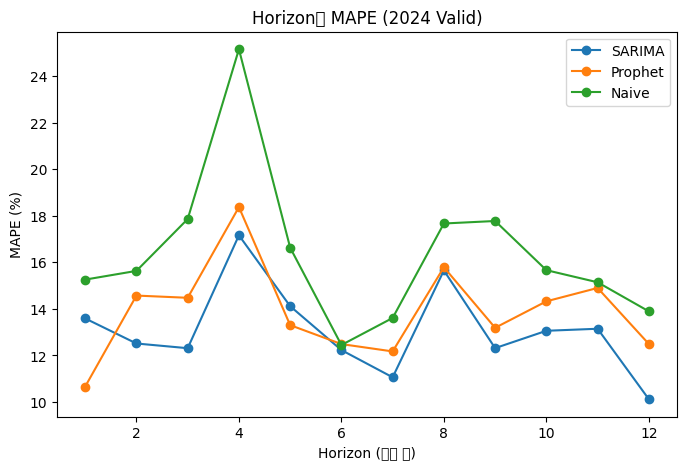

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(horizon_summary['horizon'], horizon_summary['sarima_mape'], marker='o', label='SARIMA')
ax.plot(horizon_summary['horizon'], horizon_summary['prophet_mape'], marker='o', label='Prophet')
ax.plot(horizon_summary['horizon'], horizon_summary['naive_mape'], marker='o', label='Naive')
ax.set_xlabel('Horizon (개월 뒤)')
ax.set_ylabel('MAPE (%)')
ax.set_title('Horizon별 MAPE (2024 Valid)')
ax.legend()
plt.show()

## 10. Naive 대비 개선폭
SARIMA/Prophet의 RMSE가 naive보다 얼마나 낮은지(%). 양수면 naive보다 낫다는 뜻, 음수/0에 가까우면 복잡한 모델을 쓴 보람이 없다는 뜻입니다.

In [13]:
overall = summarize(valid_long)

for model in ['sarima', 'prophet']:
    improvement = (
        (overall['naive_rmse'].iloc[0] - overall[f'{model}_rmse'].iloc[0])
        / overall['naive_rmse'].iloc[0] * 100
    )
    print(f"{model.upper()} vs Naive RMSE 개선율: {improvement:.1f}%")

SARIMA vs Naive RMSE 개선율: 20.5%
PROPHET vs Naive RMSE 개선율: 11.8%


## 11. Valid 결과 저장

In [14]:
valid_long.to_csv("sarima_prophet_valid_long_평당.csv", index=False, encoding="utf-8-sig")
horizon_summary.to_csv("sarima_prophet_valid_horizon_summary_평당.csv", index=False, encoding="utf-8-sig")

## 12. Train+Valid로 재학습 → Test(2025) 평가
8~11번에서 확인한 게 괜찮으면, 이번엔 2024년까지(train+valid)로 학습해서 2025년을 예측합니다.

In [15]:
test_long = run_forecast_loop(dong_list, VALID_END, TEST_START, TEST_END, TEST_HORIZON)
test_long = add_error_columns(test_long)

print("=== 전체 평균 (2025, 전체 동) ===")
summarize(test_long)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


=== 전체 평균 (2025, 전체 동) ===


,sarima_rmse,sarima_mae,sarima_mape,prophet_rmse,prophet_mae,prophet_mape,naive_rmse,naive_mae,naive_mape
0,1.849445,0.990687,13.566182,1.541153,0.951965,13.265607,1.551044,1.019622,14.774575


In [16]:
test_horizon_summary = summarize(test_long, group_cols='horizon')

test_long.to_csv("sarima_prophet_test_long_평당.csv", index=False, encoding="utf-8-sig")
test_horizon_summary.to_csv("sarima_prophet_test_horizon_summary_평당.csv", index=False, encoding="utf-8-sig")

test_horizon_summary

,horizon,sarima_rmse,sarima_mae,sarima_mape,prophet_rmse,prophet_mae,prophet_mape,naive_rmse,naive_mae,naive_mape
0,1,1.761238,0.981117,12.631121,1.611964,0.996428,12.920032,1.304945,0.778515,9.972706
1,2,1.253662,0.775255,11.907008,1.272469,0.831433,13.754392,1.307595,0.873377,13.455632
2,3,1.147304,0.745631,10.253105,1.066009,0.722625,9.924719,1.282292,0.968042,14.241191
3,4,1.361973,0.891384,15.382304,1.279119,0.883952,14.835437,1.618971,1.312043,23.519861
4,5,1.215497,0.885588,12.134566,1.072188,0.783927,10.649831,1.470848,1.171958,16.743475
5,6,1.396913,0.940674,13.124269,1.109772,0.824443,10.682372,1.298662,0.926044,12.503416
6,7,1.851706,0.997753,12.428973,1.853796,1.108128,13.352696,1.596961,0.988127,11.735377
7,8,2.774076,1.498074,16.578693,2.547742,1.449617,16.127168,2.480712,1.292091,14.958692
8,9,1.655020,0.889684,12.941672,1.784041,1.022638,13.753472,1.655747,1.088054,17.097236
9,10,1.896084,1.177004,17.600063,1.342827,0.985896,15.771344,1.711534,1.205005,19.453689


In [17]:
dong_rmse_2024 = valid_long.groupby('법정동코드')['sarima_se'].apply(lambda x: np.sqrt(x.mean()))
dong_rmse_2025 = test_long.groupby('법정동코드')['sarima_se'].apply(lambda x: np.sqrt(x.mean()))

compare = pd.DataFrame({'2024': dong_rmse_2024, '2025': dong_rmse_2025}).dropna()
compare['변화율'] = (compare['2025'] - compare['2024']) / compare['2024'] * 100
compare.sort_values('변화율', ascending=False).head(10)

,2024,2025,변화율
법정동코드,,,
17200.0,1.817900,8.693197,378.199926
18600.0,1.369472,3.681564,168.830904
12000.0,0.424583,1.090098,156.745791
13800.0,0.474113,0.975032,105.653783
11800.0,0.286101,0.545497,90.665691
11000.0,0.735405,1.401287,90.546333
10900.0,0.388501,0.672512,73.104527
10700.0,0.268201,0.455293,69.758340
10100.0,0.192365,0.306822,59.499639


In [18]:
total_months = raw[['계약연도', '계약월']].drop_duplicates().shape[0]

dong_txn = (
    raw.groupby('법정동코드')
    .agg(
        총거래건수=('거래건수', 'sum'),
        관측월수=('월세', lambda x: x.notna().sum())
    )
)
dong_txn['coverage'] = dong_txn['관측월수'] / total_months

dong_txn_check = dong_txn[['총거래건수', 'coverage']].join(compare, how='inner')
dong_txn_check[['총거래건수', 'coverage', '변화율']].corr()

,총거래건수,coverage,변화율
총거래건수,1.000000,0.555775,0.040047
coverage,0.555775,1.000000,-0.142407
변화율,0.040047,-0.142407,1.000000
